In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("c:\\Users\\shaba\\PycharmProjects\\Data-Analysis\\Data\\data_science_job.csv")

In [5]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
4693,31961,city_16,0.910,Female,No relevent experience,no_enrollment,Masters,Business Degree,20.0,NaN,NaN,63.0,1.0
13043,9143,city_16,0.910,NaN,Has relevent experience,no_enrollment,High School,NaN,6.0,100-500,Pvt Ltd,74.0,0.0
6778,12629,city_114,0.926,Male,No relevent experience,Full time course,Graduate,STEM,2.0,NaN,NaN,NaN,0.0
5385,15631,city_136,0.897,Male,No relevent experience,no_enrollment,Masters,Other,0.0,NaN,NaN,50.0,1.0
17653,22880,city_173,0.878,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17.0,NaN,NaN,6.0,0.0


In [6]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'training_hours', 'target'],
      dtype='object')

In [7]:
df.shape

(19158, 13)

In [8]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [11]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
3482,0.666,Full time course,Graduate,3.0,18.0
15101,0.890,no_enrollment,Graduate,15.0,74.0
12357,0.920,no_enrollment,Graduate,2.0,53.0
5504,0.624,Part time course,Graduate,7.0,17.0
13022,0.920,no_enrollment,Graduate,20.0,94.0


In [12]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [13]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

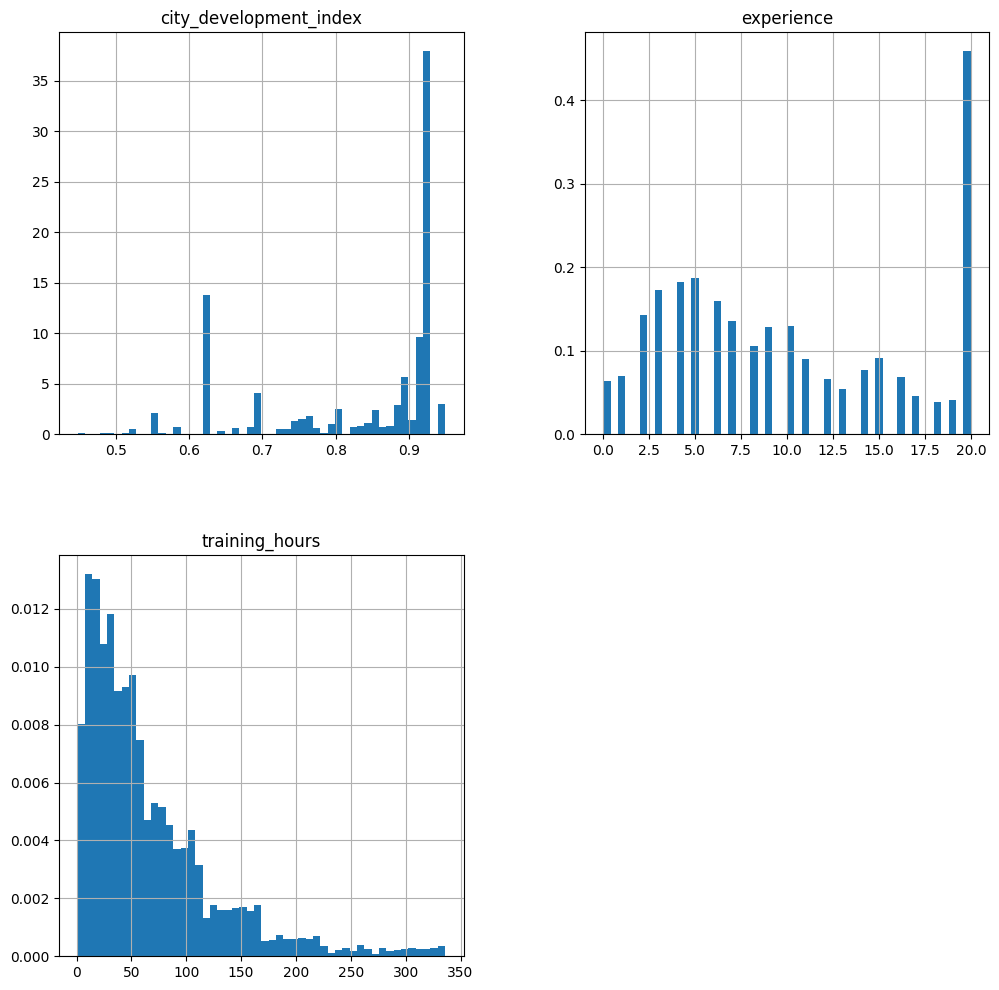

In [14]:
new_df.hist(bins = 50, density = True, figsize = (12,12))

<Axes: >

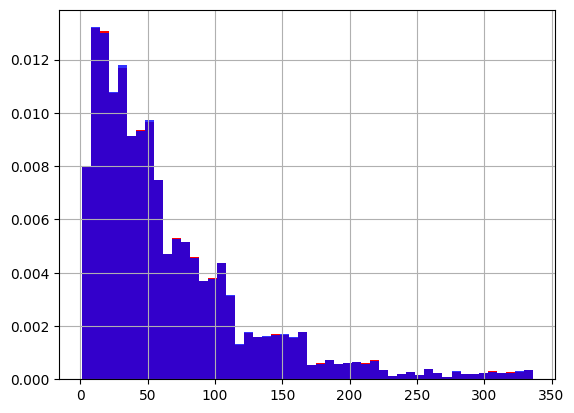

In [15]:
df['training_hours'].hist(bins = 50, density = True, color = 'r')
# After CCA
new_df['training_hours'].hist(bins =50, density = True, color = 'b', alpha = 0.8)

<Axes: xlabel='training_hours', ylabel='Density'>

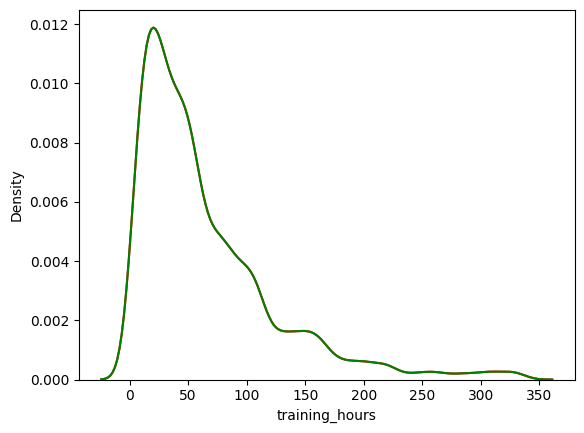

In [16]:
sns.kdeplot(df['training_hours'], color ='r')
# After CCA
sns.kdeplot(df['training_hours'], color = 'g')

<Axes: >

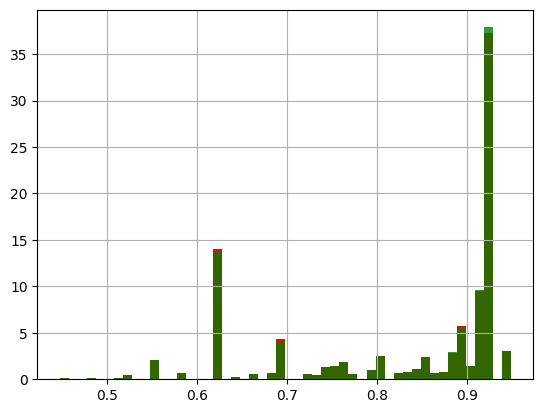

In [17]:
df['city_development_index'].hist(bins = 50, density = True, color = 'r')
# After CCA
new_df['city_development_index'].hist(bins = 50, density = True, color = 'g', alpha = 0.8)

<Axes: xlabel='city_development_index', ylabel='Density'>

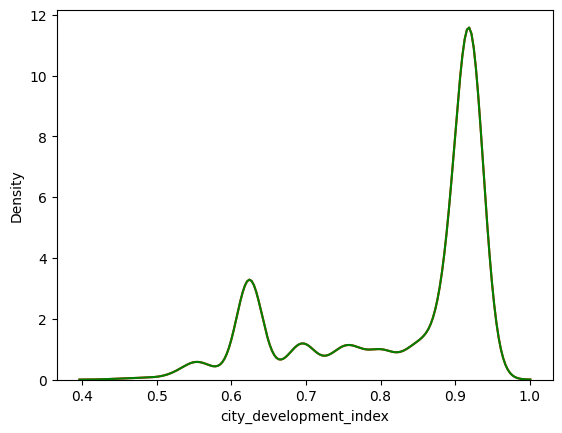

In [18]:
sns.kdeplot(df['city_development_index'], color ='r')
# After CCA
sns.kdeplot(df['city_development_index'], color = 'g')

<Axes: >

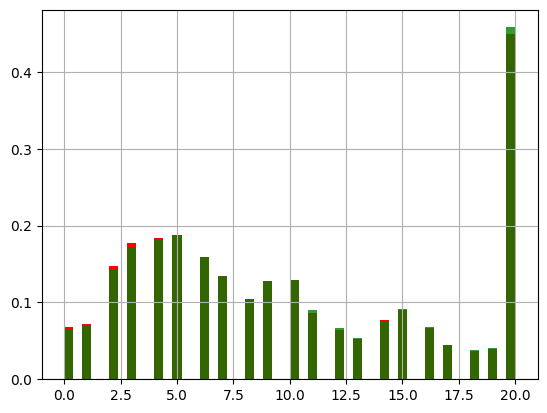

In [19]:
df['experience'].hist(bins = 50, density = True, color = 'r')
# After CCA
new_df['experience'].hist(bins = 50, density = True, color = 'g', alpha = 0.8)

<Axes: xlabel='experience', ylabel='Density'>

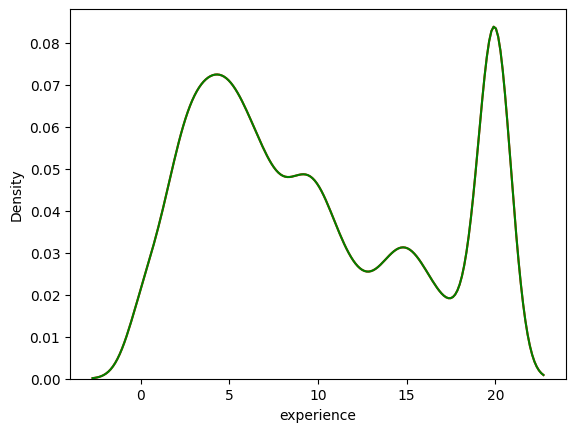

In [20]:
sns.kdeplot(df['experience'], color ='r')
# After CCA
sns.kdeplot(df['experience'], color = 'g')

([<matplotlib.patches.Wedge at 0x1ab400160d0>,
 [Text(-0.7429757805608633, 0.8111639720179737, 'no_enrollment'),
  Text(0.5665488953919868, -0.942879816906757, 'Full time course'),
  Text(1.0779657488329708, -0.21906584476584354, 'Part time course')],
 [Text(-0.4052595166695618, 0.4424530756461674, '73.6%'),
  Text(0.30902667021381097, -0.5142980819491402, '20.0%'),
  Text(0.5879813175452567, -0.11949046078136918, '6.4%')])

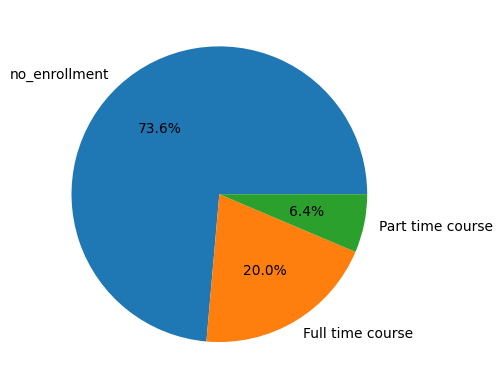

In [28]:
plt.pie(x=df['enrolled_university'].value_counts(),labels=df['enrolled_university'].value_counts().index,autopct='%1.1f%%')


([<matplotlib.patches.Wedge at 0x1ab40055f90>,
 [Text(-0.7407942973367303, 0.8131566940223638, 'no_enrollment'),
  Text(0.5632417627320795, -0.9448590988684292, 'Full time course'),
  Text(1.0777862416739987, -0.21994730563986667, 'Part time course')],
 [Text(-0.40406961672912556, 0.4435400149212893, '73.5%'),
  Text(0.3072227796720433, -0.5153776902918704, '20.1%'),
  Text(0.5878834045494538, -0.11997125762174544, '6.4%')])

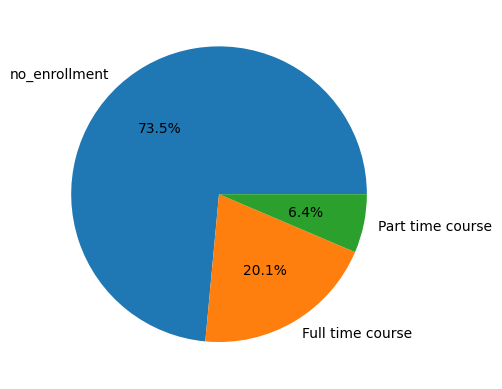

In [29]:
plt.pie(x=new_df['enrolled_university'].value_counts(),labels=new_df['enrolled_university'].value_counts().index,autopct='%1.1f%%')

In [32]:
temp = pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    
    new_df['enrolled_university'].value_counts()/len(new_df)
], axis=1
)
temp.columns = ['original','CCA']
temp

,original,CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [34]:
temp = pd.concat([
    df['education_level'].value_counts()/len(df),
    
    new_df['education_level'].value_counts()/len(new_df)
], axis=1
)
temp.columns = ['original','CCA']
temp

,original,CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
